# fio DFS All-Patterns Analysis

Analyzes `rand_write / rand_read / mixed` and `seq_write / seq_read / mixed` results
across block sizes. Two configurations are compared:

- **nj32/iod8**: numjobs=32, iodepth=8 (256 total outstanding I/Os)
- **nj16/iod16**: numjobs=16, iodepth=16 (256 total outstanding I/Os)

Both configurations maintain the same total queue depth (nj × iodepth = 256), but differ
in how parallelism is distributed: more jobs vs. deeper per-job queue. The `prefill` job
is excluded from all analysis.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [2]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    rows = []
    for job in d["jobs"]:
        name = job["jobname"]
        if name == "prefill":
            continue

        def ms(v): return v / 1e6

        if "mixed" in job:
            mx = job["mixed"]
            bw_GiBs     = mx["bw"] / 1024 / 1024
            iops        = mx["iops"]
            lat_max_ms  = ms(mx["lat_ns"]["max"])
            lat_mean_ms = ms(mx["lat_ns"]["mean"])
        else:
            r = job["read"]
            w = job["write"]
            has_read  = r["total_ios"] > 0
            has_write = w["total_ios"] > 0

            bw_GiBs = (r["bw"] * has_read + w["bw"] * has_write) / 1024 / 1024
            iops    =  r["iops"] * has_read + w["iops"] * has_write

            candidates = []
            if has_read:  candidates.append(r["lat_ns"]["max"])
            if has_write: candidates.append(w["lat_ns"]["max"])
            lat_max_ms = ms(max(candidates)) if candidates else 0

            mean_num = (r["lat_ns"]["mean"] * r["total_ios"] * has_read +
                        w["lat_ns"]["mean"] * w["total_ios"] * has_write)
            mean_den = r["total_ios"] * has_read + w["total_ios"] * has_write
            lat_mean_ms = ms(mean_num / mean_den) if mean_den > 0 else 0

        rows.append(dict(
            block_size  = bs,
            numjobs     = nj,
            iodepth     = iod,
            config      = f"nj{nj}/iod{iod}",
            pattern     = name,
            bw_GiBs     = bw_GiBs,
            iops        = iops,
            lat_mean_ms = lat_mean_ms,
            lat_max_ms  = lat_max_ms,
        ))
    return rows


all_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    all_rows.extend(parse_file(fpath))

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
PATTERN_ORDER = [
    "rand_read", "rand_readH", "rand_readB", "rand_writeH", "rand_write",
    "seq_read",  "seq_readH",  "seq_readB",  "seq_writeH", "seq_write"
]
CONFIGS = ["nj32/iod8", "nj16/iod16"]

df = pd.DataFrame(all_rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df["pattern"]    = pd.Categorical(df["pattern"],    categories=PATTERN_ORDER, ordered=True)
df = df.sort_values(["config", "block_size", "pattern"]).reset_index(drop=True)

print(f"Loaded {len(df)} jobs from {df['config'].nunique()} config(s) × {df['block_size'].nunique()} block size(s)")
for cfg in CONFIGS:
    n = len(df[df["config"] == cfg])
    print(f"  {cfg}: {n} jobs")
df

Loaded 550 jobs from 2 config(s) × 5 block size(s)
  nj32/iod8: 50 jobs
  nj16/iod16: 500 jobs


,block_size,numjobs,iodepth,config,pattern,bw_GiBs,iops,lat_mean_ms,lat_max_ms
0,4k,16,16,nj16/iod16,rand_read,2.717772,712447.894272,0.358873,41.688196
1,4k,16,16,nj16/iod16,rand_read,3.635370,952990.633802,0.268196,57.735869
2,4k,16,16,nj16/iod16,rand_read,3.228237,846263.061412,0.302066,70.017532
3,4k,16,16,nj16/iod16,rand_read,2.804466,735174.068828,0.347764,53.274218
4,4k,16,16,nj16/iod16,rand_read,2.918719,765124.754191,0.334132,49.284629
...,...,...,...,...,...,...,...,...,...
545,4m,32,8,nj32/iod8,seq_read,3.719929,952.301922,267.358874,1689.437157
546,4m,32,8,nj32/iod8,seq_readH,4.344652,1112.231004,228.768751,2054.593795
547,4m,32,8,nj32/iod8,seq_readB,8.532248,2184.255581,116.685110,565.761539
548,4m,32,8,nj32/iod8,seq_writeH,12.140118,3107.870216,81.944971,293.392045


## Run Count Summary (nj16/iod16)

In [3]:

# Run count per (pattern × block_size) — nj16/iod16 only
df16 = df[df["config"] == "nj16/iod16"]
run_counts = (
    df16.groupby(["pattern", "block_size"], observed=True)
    .size()
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(run_counts.style
    .set_caption("Number of runs per pattern × block size (nj16/iod16)")
    .format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,10,10,10,10,10
rand_readH,10,10,10,10,10
rand_readB,10,10,10,10,10
rand_writeH,10,10,10,10,10
rand_write,10,10,10,10,10
seq_read,10,10,10,10,10
seq_readH,10,10,10,10,10
seq_readB,10,10,10,10,10
seq_writeH,10,10,10,10,10


## Run-to-Run Variability (nj16/iod16)

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/fo

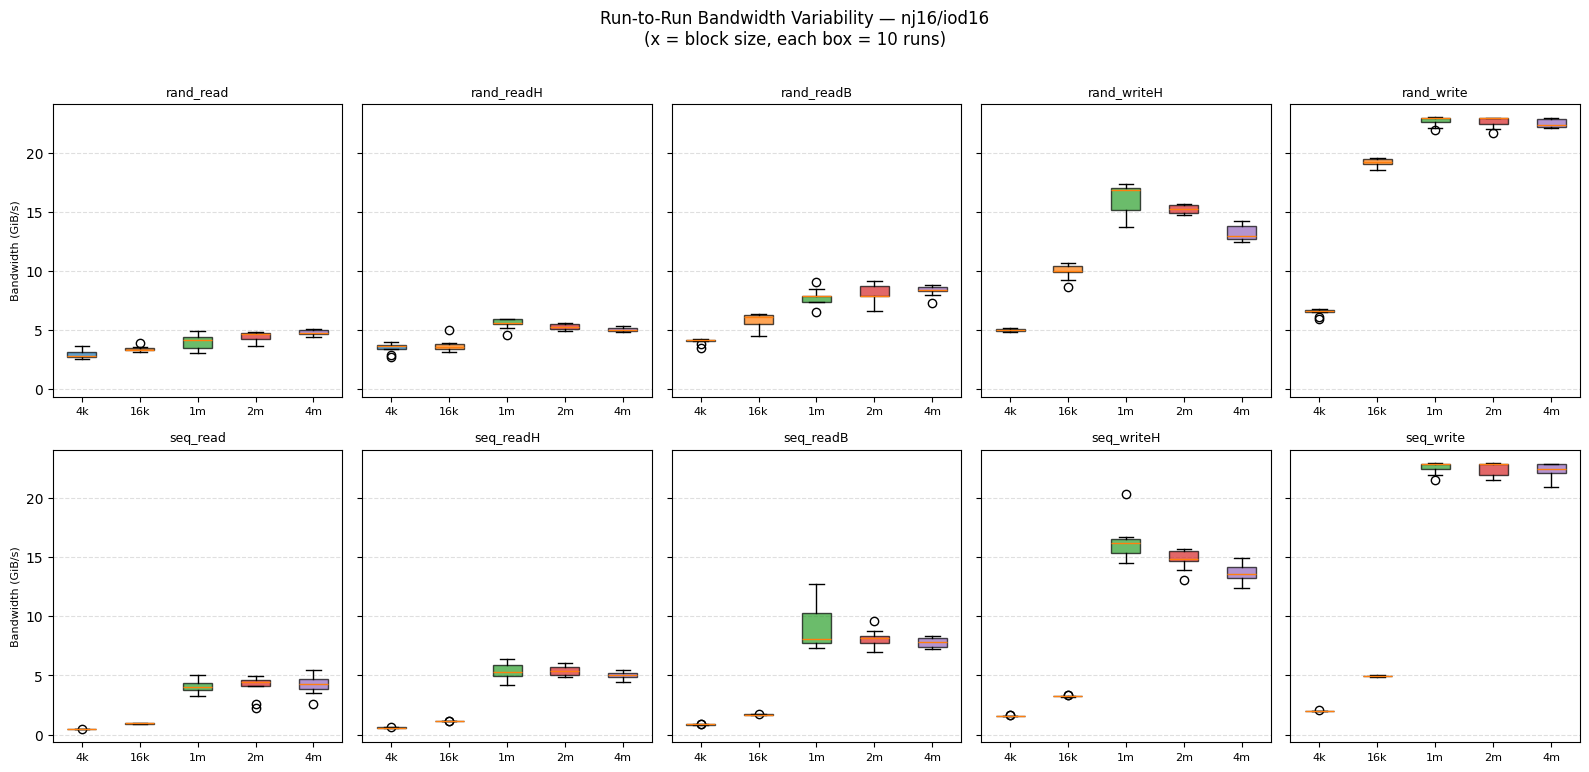

In [4]:

# Run-to-run bandwidth variability — nj16/iod16 only
# One subplot per pattern; x-axis = block sizes; shared y-axis
df16 = df[df["config"] == "nj16/iod16"]
bs_present  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
pat_present = [p for p in PATTERN_ORDER if p in df16["pattern"].unique()]

n_pat = len(pat_present)
ncols = 5
nrows = (n_pat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.8),
                         sharey=True, squeeze=False)

clrs = plt.cm.tab10.colors

for idx, pat in enumerate(pat_present):
    ax = axes[idx // ncols][idx % ncols]
    data_per_bs = [
        df16.loc[(df16["pattern"] == pat) & (df16["block_size"] == bs), "bw_GiBs"].values
        for bs in bs_present
    ]
    bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
    for patch, clr in zip(bp["boxes"], clrs[:len(bs_present)]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax.set_title(pat, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Bandwidth (GiB/s)", fontsize=8)

# Hide unused axes
for idx in range(n_pat, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle("Run-to-Run Bandwidth Variability — nj16/iod16\n(x = block size, each box = 10 runs)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "variability_boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [13]:

# CV% (std/mean × 100) for each pattern × block size — nj16/iod16
df16 = df[df["config"] == "nj16/iod16"]
cv_pivot = (
    df16.groupby(["pattern", "block_size"], observed=True)["bw_GiBs"]
    .agg(lambda x: x.std() / x.mean() * 100)
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(cv_pivot.style
    .set_caption("Coefficient of Variation (%) of bandwidth — nj16/iod16")
    .format("{:.1f}%")
    .background_gradient(cmap="YlOrRd", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,12.4%,6.7%,15.0%,8.5%,5.4%
rand_readH,11.5%,14.7%,7.6%,4.6%,3.2%
rand_readB,5.7%,12.6%,8.9%,10.3%,5.2%
rand_writeH,2.1%,6.4%,7.7%,2.4%,5.0%
rand_write,4.5%,1.8%,1.8%,2.2%,1.6%
seq_read,2.0%,1.2%,13.5%,22.8%,19.3%
seq_readH,2.0%,1.3%,12.6%,7.8%,7.0%
seq_readB,1.8%,1.6%,20.3%,9.1%,5.5%
seq_writeH,1.8%,1.4%,10.1%,5.6%,6.2%


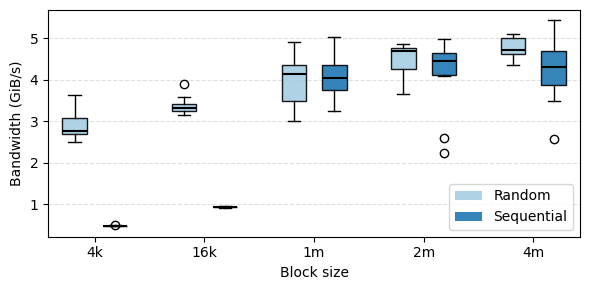

In [34]:

# Boxplot: rand_read vs seq_read — all block sizes — nj16/iod16 (publication figure)
from matplotlib.patches import Patch

ALL_BS  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
ACCESS  = ["rand", "seq"]
C_RAND  = "#a6cee3"   # Paired light-blue
C_SEQ   = "#1f78b4"   # Paired dark-blue
GAP     = 0.7

fig, ax = plt.subplots(figsize=(6, 3))

positions, data, colors, group_centers = [], [], [], []
for g, bs in enumerate(ALL_BS):
    base = g * (len(ACCESS) + GAP)
    group_centers.append(base + 0.5)
    for acc, c in zip(ACCESS, [C_RAND, C_SEQ]):
        positions.append(base + ACCESS.index(acc))
        data.append(df16.loc[
            (df16["pattern"] == f"{acc}_read") & (df16["block_size"] == bs), "bw_GiBs"
        ].values)
        colors.append(c)

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", linewidth=1.5))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)

ax.set_xticks(group_centers)
ax.set_xticklabels(ALL_BS, fontsize=10)
ax.set_xlabel("Block size", fontsize=10)
ax.set_ylabel("Bandwidth (GiB/s)", fontsize=10)
ax.set_xlim(positions[0] - 0.65, positions[-1] + 0.65)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend(handles=[
    Patch(facecolor=C_RAND, alpha=0.9, label="Random"),
    Patch(facecolor=C_SEQ,  alpha=0.9, label="Sequential"),
], fontsize=10, loc="lower right")

# ax.set_title("Read-only Bandwidth Distribution (nj16/iod16, 10 runs each)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-read-boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()blob:vscode-webview://0ov37mdvdscs9nm0bs0d6d99ejl2sqhsdodb5d127diqn2j4mu8s/0634542c-3ac8-4809-8cf0-de158e179f40


### Variability Findings (nj16/iod16)

**Run counts:** Every combination of pattern × block size has exactly **10 runs**.

**Overall:** Median coefficient of variation (CV) across all 50 pattern×BS cells is **5.4%**
(mean 6.6%). Variability is strongly pattern- and block-size-dependent.

**By pattern (mean CV across block sizes):**

| Pattern | Mean CV (%) | Character |
|---|---|---|
| `seq_read`  | 11.8 | most variable |
| `rand_read` | 9.6  | |
| `rand_readB` | 8.5 | |
| `rand_readH` | 8.3 | |
| `seq_readB`  | 7.6 | |
| `seq_readH`  | 6.1 | |
| `seq_writeH` | 5.0 | |
| `rand_writeH`| 4.7 | |
| `rand_write` | 2.4 | |
| `seq_write`  | 2.2 | most stable |

Read-dominated patterns are roughly **4–5× more variable** than write-only patterns.
Write paths are deterministic (log-append to DRAM); read paths are sensitive to DRAM
cache state, which varies between back-to-back runs.

**By block size (mean CV across patterns):**

| Block size | Mean CV (%) |
|---|---|
| 1m  | 10.0 |
| 2m  | 7.6  |
| 4m  | 6.1  |
| 16k | 4.9  |
| 4k  | 4.6  |

1 MiB block size is the most variable because it sits at the crossover between
network-latency-limited and bandwidth-saturation regimes, making it sensitive to
server-side scheduling jitter. Very small blocks (4k/16k) and very large blocks (4m)
have more predictable behavior.

**Worst single cases:** `seq_read` at 2 m (CV=22.8%), `seq_readB` at 1 m (CV=20.3%),
`seq_read` at 4 m (CV=19.3%). All are large-block sequential-read scenarios where
DAOS server prefetch and DRAM cache hit rates fluctuate across runs.

**Most stable:** `seq_write` at 16k (CV=1.0%), `rand_write` at 4m/16k (CV≈1.6–1.8%).


## Mean/Max Latency (ms)

In [14]:
pivots = {}
for cfg in CONFIGS:
    pivots[cfg] = (
        df[df["config"] == cfg]
        .pivot_table(index="pattern", columns="block_size", values="lat_mean_ms", aggfunc="median")
        .reindex(index=[p for p in PATTERN_ORDER if p in df["pattern"].unique()],
                 columns=[b for b in BS_ORDER if b in df["block_size"].unique()])
    )

# Side-by-side: MultiIndex columns (config, block_size)
lat_table = pd.concat(pivots, axis=1)
lat_table.columns.names = ["config", "block_size"]

display(lat_table.round(3).style
    .set_caption("Median Latency (ms) — nj16/iod16 vs nj32/iod8")
    .format("{:.3f}")
    .background_gradient(cmap="YlOrRd", axis=None)
)

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2449558274.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="pattern", columns="block_size", values="lat_mean_ms", aggfunc="median")
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2449558274.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="pattern", columns="block_size", values="lat_mean_ms", aggfunc="median")


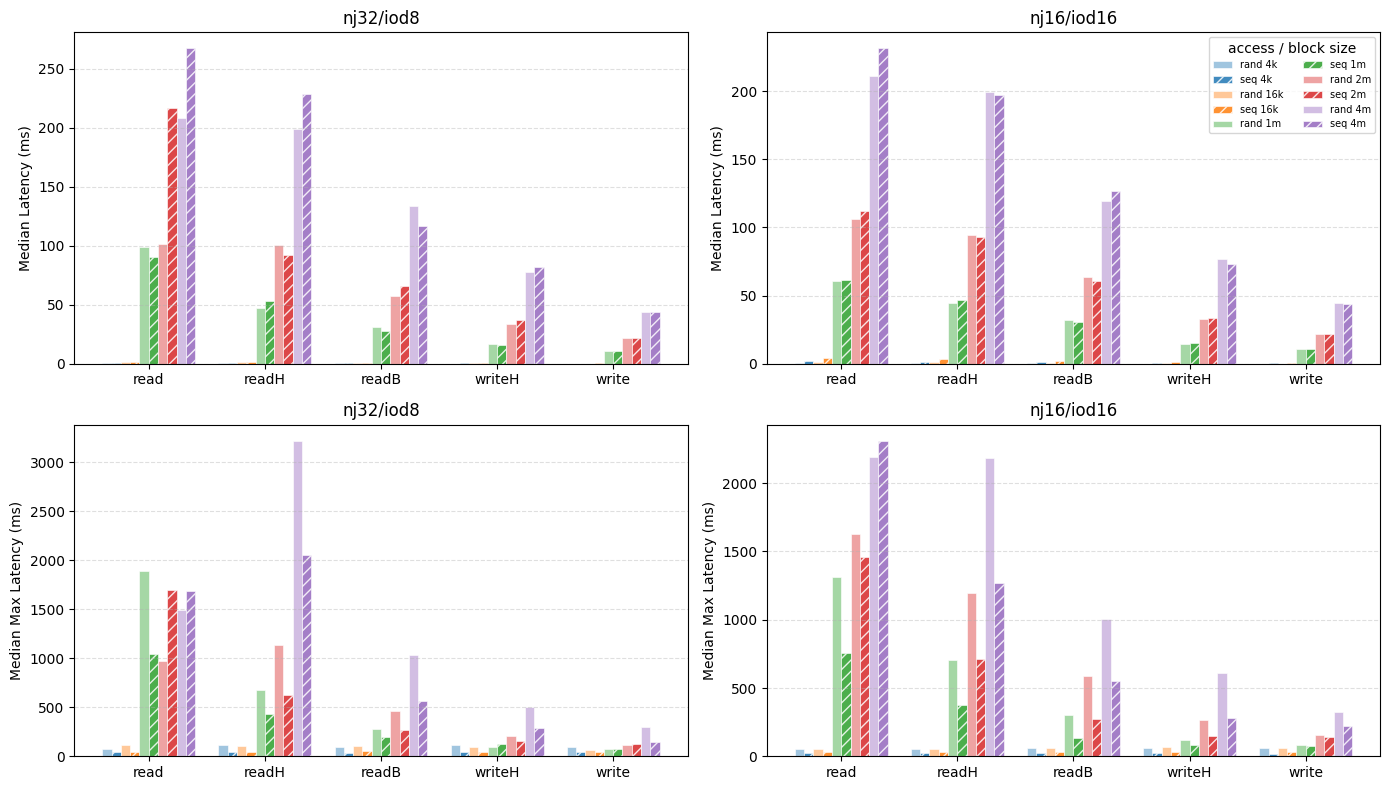

In [15]:
BASE_OPS = ["read", "readH", "readB", "writeH", "write"]
ACCESS   = ["rand", "seq"]
_hatches = {"rand": "", "seq": "///"}

def plot_metric(ax, col, cfg):
    df_sub  = df[df["config"] == cfg]
    bs_l    = sorted(df_sub["block_size"].unique(), key=lambda b: BS_ORDER.index(b))
    combos  = [(acc, bs) for bs in bs_l for acc in ACCESS]
    n       = len(combos)
    bar_w   = 0.8 / n
    x       = list(range(len(BASE_OPS)))
    offsets = [(i - (n - 1) / 2) * bar_w for i in range(n)]
    clrs    = plt.cm.tab10.colors

    sub_all = df_sub.groupby(["block_size", "pattern"], observed=True)[col].median()
    for i, (acc, bs) in enumerate(combos):
        vals     = [sub_all.get((bs, f"{acc}_{op}"), 0) for op in BASE_OPS]
        base_clr = clrs[bs_l.index(bs)]
        bar_clr  = tuple(c * 0.5 + 0.5 for c in base_clr[:3]) if acc == "rand" else base_clr
        ax.bar([xi + offsets[i] for xi in x], vals, bar_w,
               label=f"{acc} {bs}",
               color=bar_clr,
               hatch=_hatches[acc], alpha=0.85, edgecolor="white", linewidth=0.5)
    return x, bs_l

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (col, ylabel) in enumerate([
    ("lat_mean_ms", "Median Latency (ms)"),
    ("lat_max_ms",  "Median Max Latency (ms)"),
]):
    for col_idx, cfg in enumerate(CONFIGS):
        ax = axes[row_idx][col_idx]
        x_ticks, _ = plot_metric(ax, col, cfg)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(BASE_OPS)
        ax.set_ylabel(ylabel)
        ax.set_title(cfg)
        if row_idx == 0 and col_idx == 1:
            ax.legend(title="access / block size", loc="upper right", ncol=2, fontsize=7)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency-all-pattern.pdf", dpi=150)
plt.show()

## Bandwidth (GiB/s)

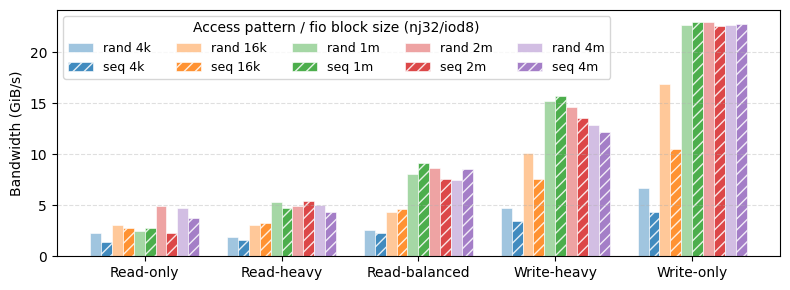

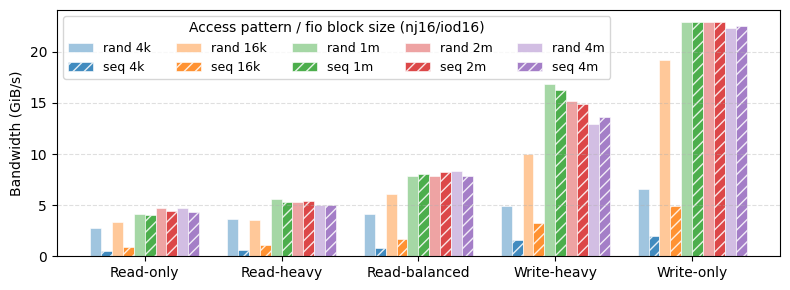

In [16]:
OP_LABELS = ["Read-only", "Read-heavy", "Read-balanced", "Write-heavy", "Write-only"]

for cfg in CONFIGS:
    fig, ax = plt.subplots(figsize=(8, 3))
    x_ticks, _ = plot_metric(ax, "bw_GiBs", cfg)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(OP_LABELS, ha="center")
    ax.set_ylabel("Bandwidth (GiB/s)")
    # ax.set_title(cfg)
    ax.legend(title=f"Access pattern / fio block size ({cfg})", loc="upper left", ncol=5, fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    fname = f"fio-bw-all-pattern-{cfg.replace('/', '-')}.pdf"
    plt.savefig(RESULTS_DIR / fname, dpi=150)
    plt.show()

In [17]:

# Random vs Sequential bandwidth comparison
# ratio = (rand_bw / seq_bw - 1) * 100; positive = random outperforms sequential

OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
OP_LABEL_MAP = {
    "read":   "Read-only",
    "readH":  "Read-heavy",
    "readB":  "Read-balanced",
    "writeH": "Write-heavy",
    "write":  "Write-only",
}

med = (
    df.groupby(["config", "block_size", "pattern"], observed=True)["bw_GiBs"]
    .median()
    .reset_index()
)

rows = []
for cfg in CONFIGS:
    for bs in BS_ORDER:
        if bs not in med["block_size"].values:
            continue
        for op in OP_SUFFIXES:
            rand_row = med[(med["config"] == cfg) & (med["block_size"] == bs) & (med["pattern"] == f"rand_{op}")]
            seq_row  = med[(med["config"] == cfg) & (med["block_size"] == bs) & (med["pattern"] == f"seq_{op}")]
            if rand_row.empty or seq_row.empty:
                continue
            r_bw = rand_row["bw_GiBs"].values[0]
            s_bw = seq_row["bw_GiBs"].values[0]
            rows.append(dict(
                config        = cfg,
                workload      = OP_LABEL_MAP[op],
                block_size    = bs,
                rand_GiBs     = r_bw,
                seq_GiBs      = s_bw,
                rand_vs_seq   = (r_bw / s_bw - 1) * 100,
            ))

comp = pd.DataFrame(rows)
comp["block_size"] = pd.Categorical(comp["block_size"], categories=BS_ORDER, ordered=True)
workload_order = [OP_LABEL_MAP[op] for op in OP_SUFFIXES]
bs_present = [b for b in BS_ORDER if b in comp["block_size"].cat.categories and
              b in comp["block_size"].values]

for cfg in CONFIGS:
    sub = comp[comp["config"] == cfg]

    # Detailed table: rand bw, seq bw, ratio — MultiIndex columns
    detail = sub.set_index(["workload", "block_size"])[["rand_GiBs", "seq_GiBs", "rand_vs_seq"]]
    detail = detail.unstack("block_size").reindex(workload_order, level=0)
    detail.columns = pd.MultiIndex.from_tuples(
        [(metric, bs) for metric, bs in detail.columns],
        names=["metric", "block_size"]
    )
    # Reorder columns so metrics are in logical order, block sizes in BS_ORDER
    col_order = [(m, b) for m in ["rand_GiBs", "seq_GiBs", "rand_vs_seq"] for b in bs_present
                 if (m, b) in detail.columns]
    detail = detail[col_order]

    def fmt(col, val):
        if "rand_vs_seq" in col:
            return f"{val:+.1f}%"
        return f"{val:.2f}"

    print(f"\n=== {cfg} ===")
    display(detail.style
        .set_caption(
            f"Random vs Sequential — median bandwidth (GiB/s) and ratio [{cfg}]\n"
            "rand_vs_seq = (rand / seq − 1) × 100%; positive = random faster"
        )
        .format(lambda v: f"{v:.2f}", subset=[c for c in detail.columns if "rand_vs_seq" not in c[0]])
        .format(lambda v: f"{v:+.1f}%", subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
        .background_gradient(cmap="RdYlGn", axis=None,
                             subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
    )

    # Compact ratio-only pivot
    pivot = (
        sub.pivot(index="workload", columns="block_size", values="rand_vs_seq")
        .reindex(index=workload_order, columns=bs_present)
    )
    display(pivot.style
        .set_caption(f"rand_vs_seq (%) summary — {cfg}  [positive = random faster]")
        .format("{:+.1f}%")
        .background_gradient(cmap="RdYlGn", axis=None)
    )



=== nj32/iod8 ===


block_size,4k,16k,1m,2m,4m
workload,,,,,
Read-only,+61.4%,+12.6%,-8.7%,+114.2%,+28.4%
Read-heavy,+20.0%,-6.1%,+12.8%,-8.7%,+14.9%
Read-balanced,+12.1%,-7.0%,-11.3%,+15.3%,-13.0%
Write-heavy,+36.9%,+33.0%,-3.3%,+7.7%,+5.7%
Write-only,+54.4%,+60.8%,-1.2%,+1.8%,-0.4%



=== nj16/iod16 ===


block_size,4k,16k,1m,2m,4m
workload,,,,,
Read-only,+481.2%,+254.5%,+2.0%,+5.0%,+9.5%
Read-heavy,+517.5%,+208.7%,+4.8%,-1.5%,-1.1%
Read-balanced,+381.8%,+260.0%,-2.8%,-4.4%,+6.6%
Write-heavy,+214.1%,+208.0%,+3.6%,+2.3%,-4.8%
Write-only,+229.8%,+288.1%,+0.1%,+0.1%,-0.7%


## CPU Usage (usr / sys)

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2910905262.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_usr = df_c.pivot_table(index="pattern", columns="block_size", values="usr_cpu", aggfunc="median")
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2910905262.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sys = df_c.pivot_table(index="pattern", columns="block_size", values="sys_cpu", aggfunc="median")
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2910905262.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pa

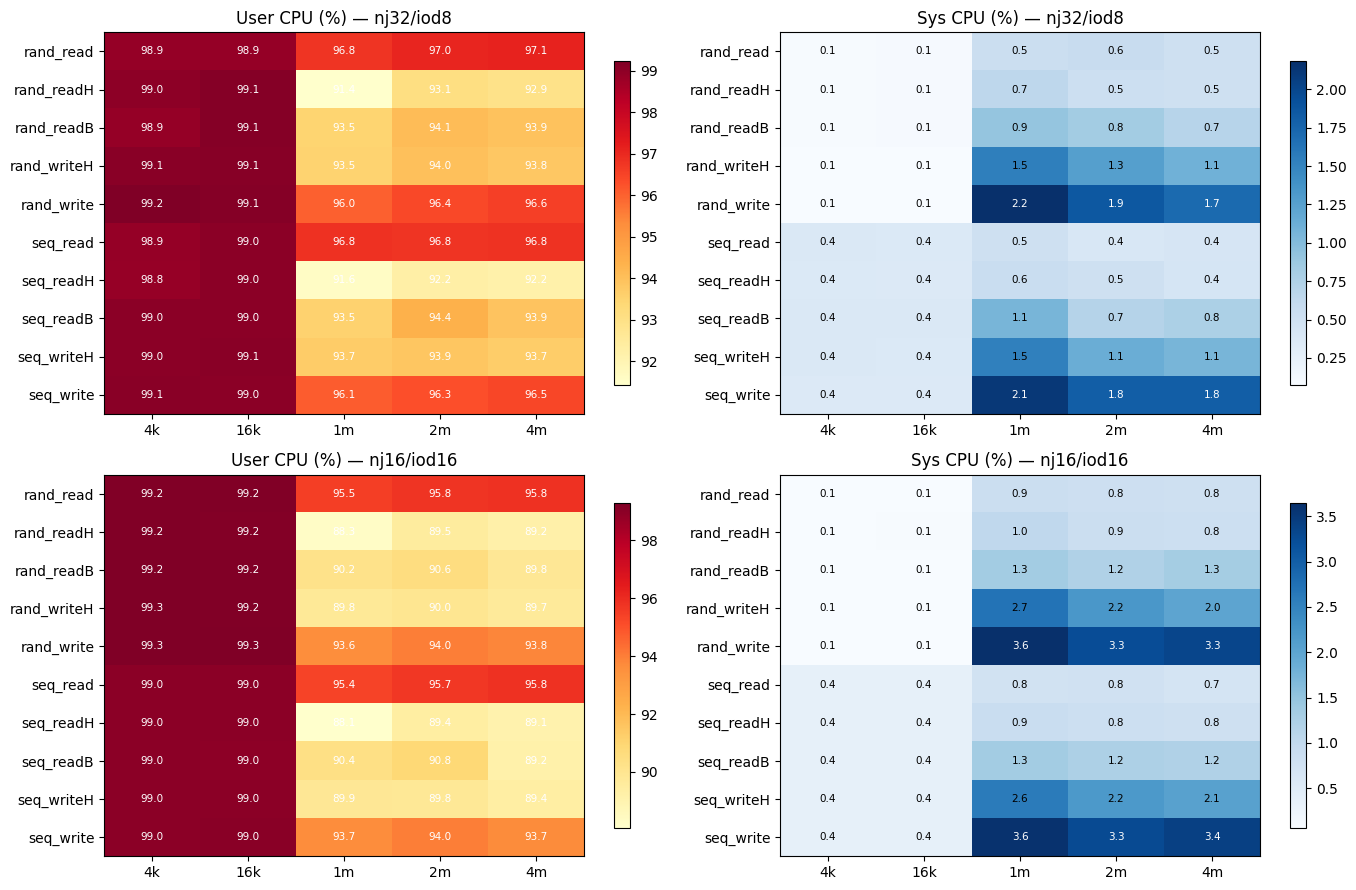

In [18]:
cpu_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))
    cfg = f"nj{nj}/iod{iod}"
    with open(fpath) as f:
        d = json.load(f)
    for job in d["jobs"]:
        if job["jobname"] == "prefill":
            continue
        cpu_rows.append(dict(
            block_size = bs,
            config     = cfg,
            pattern    = job["jobname"],
            usr_cpu    = job["usr_cpu"],
            sys_cpu    = job["sys_cpu"],
        ))

df_cpu = pd.DataFrame(cpu_rows)
df_cpu["block_size"] = pd.Categorical(df_cpu["block_size"], categories=BS_ORDER, ordered=True)
df_cpu["pattern"]    = pd.Categorical(df_cpu["pattern"],    categories=PATTERN_ORDER, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row_idx, cfg in enumerate(CONFIGS):
    df_c = df_cpu[df_cpu["config"] == cfg]
    pivot_usr = df_c.pivot_table(index="pattern", columns="block_size", values="usr_cpu", aggfunc="median")
    pivot_sys = df_c.pivot_table(index="pattern", columns="block_size", values="sys_cpu", aggfunc="median")
    for col_idx, (pivot, title, cmap) in enumerate([
        (pivot_usr, f"User CPU (%) — {cfg}", "YlOrRd"),
        (pivot_sys, f"Sys CPU (%) — {cfg}",  "Blues"),
    ]):
        ax = axes[row_idx][col_idx]
        im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                       vmin=pivot.values.min(), vmax=pivot.values.max())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, shrink=0.85)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                        ha="center", va="center", fontsize=7.5,
                        color="black" if pivot.values[i, j] < pivot.values.max() * 0.75 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Comparison: nj16/iod16 vs nj32/iod8

Both configurations use 256 total outstanding I/Os (nj × iodepth = 32×8 = 16×16).
The heatmaps show the **percentage change** when switching from nj32/iod8 to nj16/iod16.
- **Bandwidth**: green = nj16/iod16 is faster; red = nj32/iod8 is faster.
- **Mean latency**: green = nj16/iod16 has lower latency; red = nj16/iod16 has higher latency.

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2709756489.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="pattern", columns="block_size", values=col, aggfunc="median")
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2709756489.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="pattern", columns="block_size", values=col, aggfunc="median")
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_79155/2709756489.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this wa

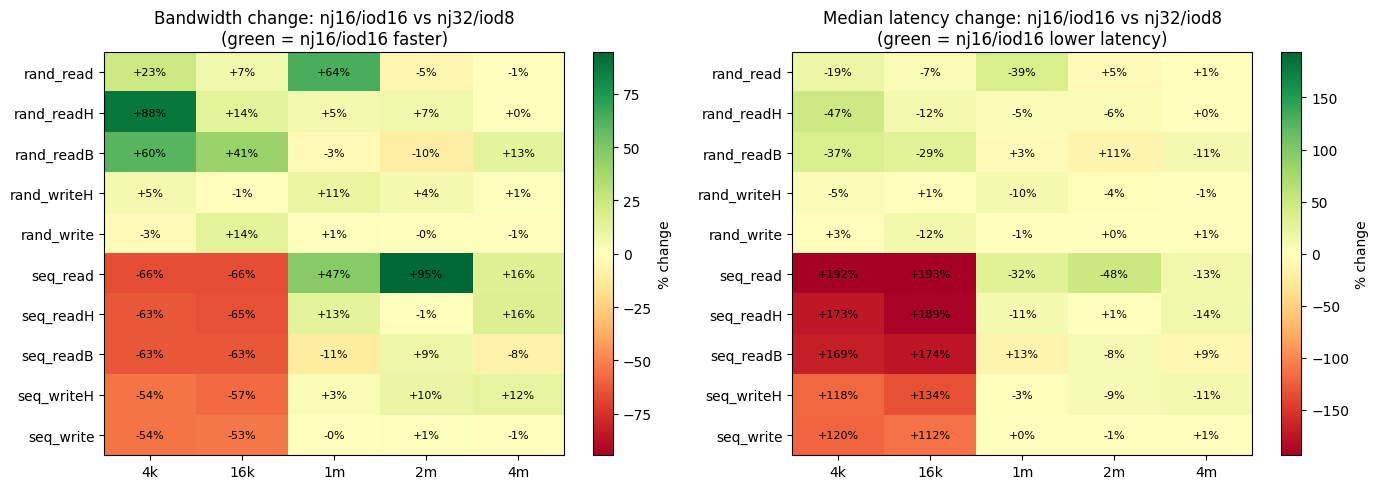

In [19]:
def make_pivot(col, cfg):
    return (df[df["config"] == cfg]
            .pivot_table(index="pattern", columns="block_size", values=col, aggfunc="median")
            .reindex(PATTERN_ORDER))

bw_32_8   = make_pivot("bw_GiBs",     "nj32/iod8")
bw_16_16  = make_pivot("bw_GiBs",     "nj16/iod16")
lat_32_8  = make_pivot("lat_mean_ms", "nj32/iod8")
lat_16_16 = make_pivot("lat_mean_ms", "nj16/iod16")

bw_ratio  = (bw_16_16  / bw_32_8  - 1) * 100   # positive = nj16/iod16 faster
lat_ratio = (lat_16_16 / lat_32_8 - 1) * 100   # positive = nj16/iod16 slower

def draw_ratio_heatmap(ax, mat, title, cmap, cb_label, invert_sign=False):
    vals = mat.values
    finite = vals[~(vals != vals)]  # exclude NaN
    if len(finite) == 0:
        return
    vmax = max(abs(vals[~(vals != vals)].min() if len(finite) else 0),
               abs(vals[~(vals != vals)].max() if len(finite) else 0))
    vmax = max(vmax, 1.0)
    sign = -1 if invert_sign else 1
    im = ax.imshow(sign * vals, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=cb_label)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            v = vals[i, j]
            if v == v:  # not NaN
                ax.text(j, i, f"{v:+.0f}%", ha="center", va="center",
                        fontsize=8, color="black")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

draw_ratio_heatmap(
    axes[0], bw_ratio,
    "Bandwidth change: nj16/iod16 vs nj32/iod8\n(green = nj16/iod16 faster)",
    "RdYlGn", "% change"
)
draw_ratio_heatmap(
    axes[1], lat_ratio,
    "Median latency change: nj16/iod16 vs nj32/iod8\n(green = nj16/iod16 lower latency)",
    "RdYlGn", "% change",
    invert_sign=True   # negate so negative (lower lat) maps to green end
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "config_comparison_ratio.pdf", dpi=150)
plt.show()